In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("torch:", torch.__version__)

torch: 2.10.0+cpu


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Define paths
ROOT = Path.cwd() if Path.cwd().name == "HW12" else Path("homeworks") / "HW12"
ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_PATH = ROOT / "data" / "S12-hw-dataset.csv"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

Device: cpu


Rows: 4320
Date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Missing values:
 date      0
target    0
dtype: int64


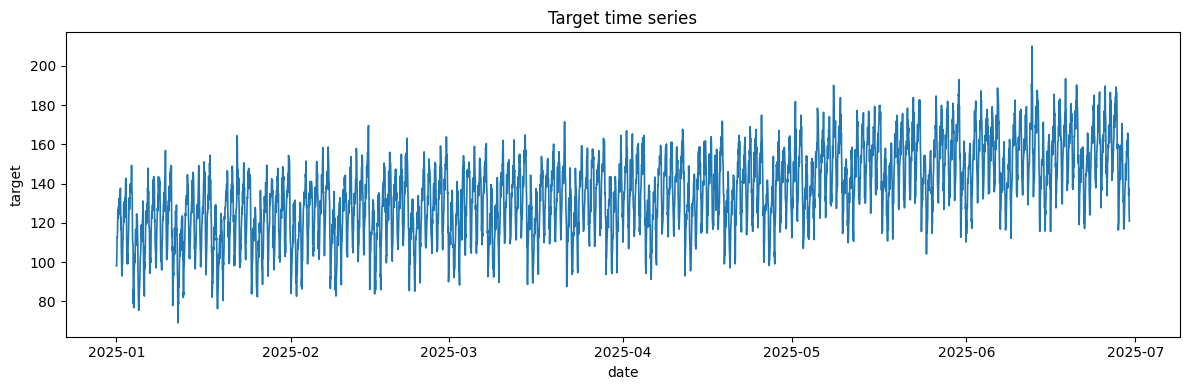

In [ ]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["date"].min(), "->", df["date"].max())
print("Missing values:\n", df.isna().sum())

# %%
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["target"], lw=1.2)
plt.title("Target time series")
plt.xlabel("date")
plt.ylabel("target")
plt.tight_layout()
plt.show()

Split sizes: 3024 / 648 / 648
Train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
Val  : 2025-05-07 00:00:00 -> 2025-06-02 23:00:00
Test : 2025-06-03 00:00:00 -> 2025-06-29 23:00:00


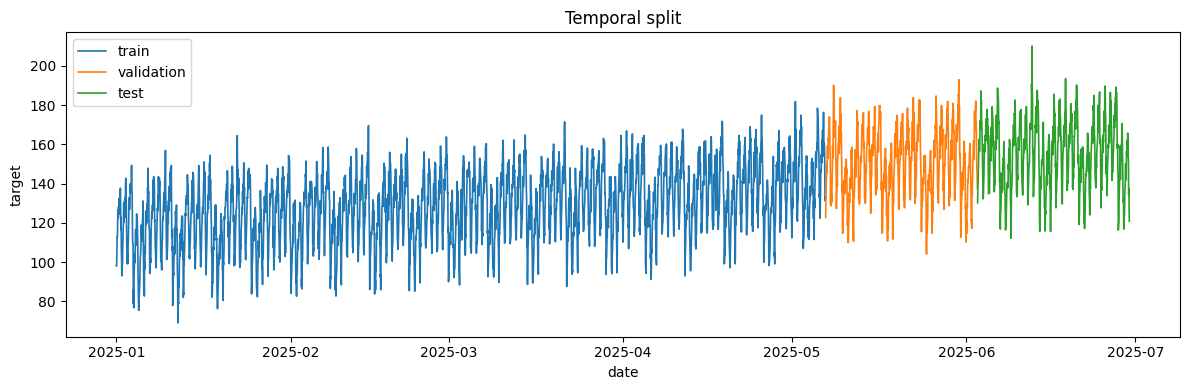

In [4]:
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print(f"Split sizes: {len(train_df)} / {len(val_df)} / {len(test_df)}")
print(f"Train: {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"Val  : {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"Test : {test_df['date'].min()} -> {test_df['date'].max()}")

# %%
plt.figure(figsize=(12, 4))
plt.plot(train_df["date"], train_df["target"], label="train", lw=1.2)
plt.plot(val_df["date"],   val_df["target"],   label="validation", lw=1.2)
plt.plot(test_df["date"],  test_df["target"],  label="test", lw=1.2)
plt.title("Temporal split")
plt.xlabel("date")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=140)
plt.show()

In [5]:
feat_df = df.copy()
feat_df["lag_1"]  = feat_df["target"].shift(1)
feat_df["lag_7"]  = feat_df["target"].shift(7)
feat_df["lag_14"] = feat_df["target"].shift(14)
feat_df["rolling_mean_7"] = feat_df["target"].shift(1).rolling(7).mean()
feat_df["rolling_std_7"]  = feat_df["target"].shift(1).rolling(7).std()
feat_df["dow"]   = feat_df["date"].dt.dayofweek
feat_df["hour"]  = feat_df["date"].dt.hour
feat_df["ma_24"] = feat_df["target"].shift(1).rolling(24).mean()   # for B2

feat_df = feat_df.dropna().reset_index(drop=True)
print("Rows after feature building:", len(feat_df))

# Split features by the same temporal boundaries
cut_train_date = train_df["date"].max()
cut_val_date   = val_df["date"].max()

feat_train = feat_df[feat_df["date"] <= cut_train_date].copy()
feat_val   = feat_df[(feat_df["date"] > cut_train_date) & (feat_df["date"] <= cut_val_date)].copy()
feat_test  = feat_df[feat_df["date"] > cut_val_date].copy()

print(f"Feature split sizes: {len(feat_train)} / {len(feat_val)} / {len(feat_test)}")

Rows after feature building: 4296
Feature split sizes: 3000 / 648 / 648


In [6]:
def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100

def calc_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": float(mape(y_true, y_pred)),
    }

def print_metrics(tag, m):
    print(f"{tag}: MAE={m['mae']:.4f} | RMSE={m['rmse']:.4f} | MAPE={m['mape']:.2f}%")

In [7]:
val_true = feat_val["target"].values

# ----- B1: naive‑last -----
val_pred_b1 = feat_val["lag_1"].values
metrics_b1_val = calc_metrics(val_true, val_pred_b1)
print_metrics("B1 val", metrics_b1_val)

# ----- B2: moving average (window 24) -----
val_pred_b2 = feat_val["ma_24"].values
metrics_b2_val = calc_metrics(val_true, val_pred_b2)
print_metrics("B2 val", metrics_b2_val)

# ----- B3: Ridge with lag/rolling/calendar features -----
feature_cols = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dow", "hour"]
X_train = feat_train[feature_cols].values
y_train = feat_train["target"].values
X_val   = feat_val[feature_cols].values

scaler_b3 = StandardScaler()
X_train_scaled = scaler_b3.fit_transform(X_train)
X_val_scaled   = scaler_b3.transform(X_val)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, y_train)
val_pred_b3 = ridge.predict(X_val_scaled)
metrics_b3_val = calc_metrics(val_true, val_pred_b3)
print_metrics("B3 val", metrics_b3_val)

B1 val: MAE=6.4448 | RMSE=8.2010 | MAPE=4.40%
B2 val: MAE=13.3980 | RMSE=16.1699 | MAPE=9.20%
B3 val: MAE=6.3632 | RMSE=7.8888 | MAPE=4.28%


In [8]:
# Scale target using StandardScaler (fit only on train)
target_scaler = StandardScaler()
target_scaled = target_scaler.fit_transform(df[["target"]]).squeeze(-1)

window_size = 24
horizon = 1

class SeqDataset(Dataset):
    def __init__(self, series, start_idx, end_idx, window):
        self.x = []
        self.y = []
        # Predict t using [t-window .. t-1]
        for t in range(max(window, start_idx), end_idx):
            self.x.append(series[t - window:t])
            self.y.append(series[t])
        self.x = torch.tensor(np.array(self.x), dtype=torch.float32).unsqueeze(-1)  # (samples, window, 1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = SeqDataset(target_scaled, 0, train_end, window_size)
val_ds   = SeqDataset(target_scaled, train_end, val_end, window_size)
test_ds  = SeqDataset(target_scaled, val_end, n, window_size)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

print(f"GRU dataset sizes: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")

GRU dataset sizes: train=3000, val=648, test=648


In [9]:
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.head(last)

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, ys = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pr = model(xb)
        preds.append(pr.cpu().numpy())
        ys.append(yb.cpu().numpy())
    preds = np.concatenate(preds, axis=0).squeeze(-1)
    ys   = np.concatenate(ys, axis=0).squeeze(-1)
    return preds, ys

def inverse_scale(arr_1d):
    return target_scaler.inverse_transform(arr_1d.reshape(-1, 1)).squeeze(-1)

gru = GRURegressor(hidden_size=64).to(device)
optimizer = torch.optim.Adam(gru.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 20

history = {"train_loss": [], "val_mae": [], "val_rmse": [], "val_mape": []}
best_val_mae = float("inf")
best_state = None

for epoch in range(1, epochs + 1):
    gru.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = gru(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    train_loss = np.mean(losses)
    val_pred_scaled, val_true_scaled = predict_loader(gru, val_loader)
    val_pred = inverse_scale(val_pred_scaled)
    val_true_r = inverse_scale(val_true_scaled)
    val_m = calc_metrics(val_true_r, val_pred)

    history["train_loss"].append(train_loss)
    history["val_mae"].append(val_m["mae"])
    history["val_rmse"].append(val_m["rmse"])
    history["val_mape"].append(val_m["mape"])

    if val_m["mae"] < best_val_mae:
        best_val_mae = val_m["mae"]
        best_state = {k: v.cpu().clone() for k, v in gru.state_dict().items()}

    print(f"Epoch {epoch:02d}: train_loss={train_loss:.5f} val_mae={val_m['mae']:.4f}")

gru.load_state_dict(best_state)
val_pred_r1_scaled, val_true_r1_scaled = predict_loader(gru, val_loader)
val_pred_r1 = inverse_scale(val_pred_r1_scaled)
val_true_r1 = inverse_scale(val_true_r1_scaled)
metrics_r1_val = calc_metrics(val_true_r1, val_pred_r1)
print_metrics("R1 val", metrics_r1_val)

# Save best GRU model and config
torch.save(gru.state_dict(), ARTIFACTS_DIR / "best_gru.pt")
best_gru_config = {
    "seed": SEED,
    "window_size": window_size,
    "horizon": horizon,
    "hidden_size": 64,
    "num_layers": 1,
    "batch_size": batch_size,
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": epochs,
    "scaler": "StandardScaler(target)",
    "best_val_mae": metrics_r1_val["mae"],
    "best_val_rmse": metrics_r1_val["rmse"],
    "best_val_mape": metrics_r1_val["mape"],
}
with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=2)

Epoch 01: train_loss=0.59249 val_mae=13.6675
Epoch 02: train_loss=0.20781 val_mae=7.5611
Epoch 03: train_loss=0.13403 val_mae=7.0578
Epoch 04: train_loss=0.12418 val_mae=6.4418
Epoch 05: train_loss=0.11700 val_mae=7.5263
Epoch 06: train_loss=0.11374 val_mae=6.2347
Epoch 07: train_loss=0.11116 val_mae=6.7714
Epoch 08: train_loss=0.10977 val_mae=7.0933
Epoch 09: train_loss=0.10920 val_mae=6.1912
Epoch 10: train_loss=0.10192 val_mae=6.0869
Epoch 11: train_loss=0.08760 val_mae=5.7044
Epoch 12: train_loss=0.08249 val_mae=5.8957
Epoch 13: train_loss=0.08033 val_mae=5.7378
Epoch 14: train_loss=0.08027 val_mae=5.7133
Epoch 15: train_loss=0.07824 val_mae=5.6648
Epoch 16: train_loss=0.07948 val_mae=5.6011
Epoch 17: train_loss=0.07805 val_mae=5.5480
Epoch 18: train_loss=0.07628 val_mae=5.6765
Epoch 19: train_loss=0.07656 val_mae=5.7220
Epoch 20: train_loss=0.07663 val_mae=5.4121
R1 val: MAE=5.4121 | RMSE=6.9264 | MAPE=3.67%


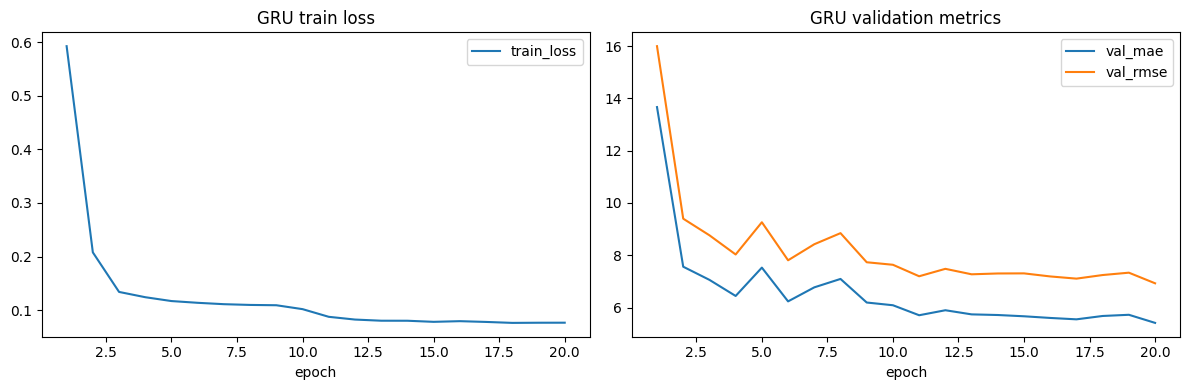

In [10]:
ep = np.arange(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ep, history["train_loss"], label="train_loss")
ax[0].set_title("GRU train loss")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(ep, history["val_mae"], label="val_mae")
ax[1].plot(ep, history["val_rmse"], label="val_rmse")
ax[1].set_title("GRU validation metrics")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=140)
plt.show()

Best by validation MAE: R1 {'mae': 5.412137985229492, 'rmse': 6.926396187184625, 'mape': 3.670032262802124}


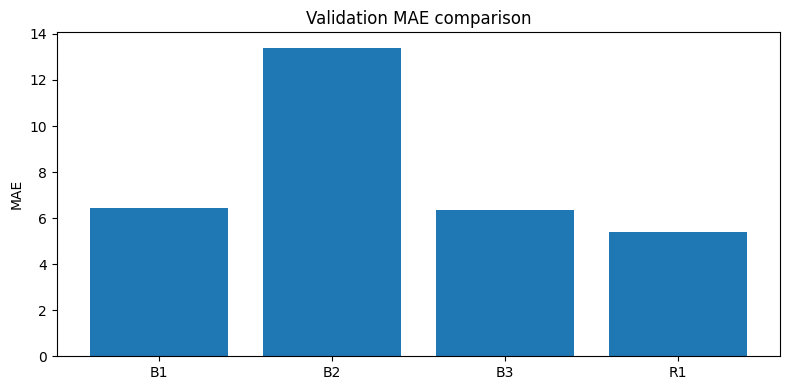

In [11]:
val_results = {
    "B1": metrics_b1_val,
    "B2": metrics_b2_val,
    "B3": metrics_b3_val,
    "R1": metrics_r1_val,
}
best_exp = min(val_results, key=lambda k: val_results[k]["mae"])
print("Best by validation MAE:", best_exp, val_results[best_exp])

plt.figure(figsize=(8, 4))
labels = ["B1", "B2", "B3", "R1"]
vals = [val_results[k]["mae"] for k in labels]
plt.bar(labels, vals)
plt.title("Validation MAE comparison")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_compare.png", dpi=140)
plt.show()

In [12]:
def eval_baseline_on_test(which):
    y_true = feat_test["target"].values
    if which == "B1":
        y_pred = feat_test["lag_1"].values
    elif which == "B2":
        y_pred = feat_test["ma_24"].values
    elif which == "B3":
        X_t = feat_test[feature_cols].values
        y_pred = ridge.predict(scaler_b3.transform(X_t))
    else:
        raise ValueError(which)
    return y_true, y_pred, calc_metrics(y_true, y_pred)

if best_exp == "R1":
    test_pred_scaled, test_true_scaled = predict_loader(gru, test_loader)
    y_pred_test = inverse_scale(test_pred_scaled)
    y_true_test = inverse_scale(test_true_scaled)
    best_test_metrics = calc_metrics(y_true_test, y_pred_test)
else:
    y_true_test, y_pred_test, best_test_metrics = eval_baseline_on_test(best_exp)

print_metrics(f"{best_exp} test", best_test_metrics)

R1 test: MAE=6.0113 | RMSE=7.6365 | MAPE=3.91%


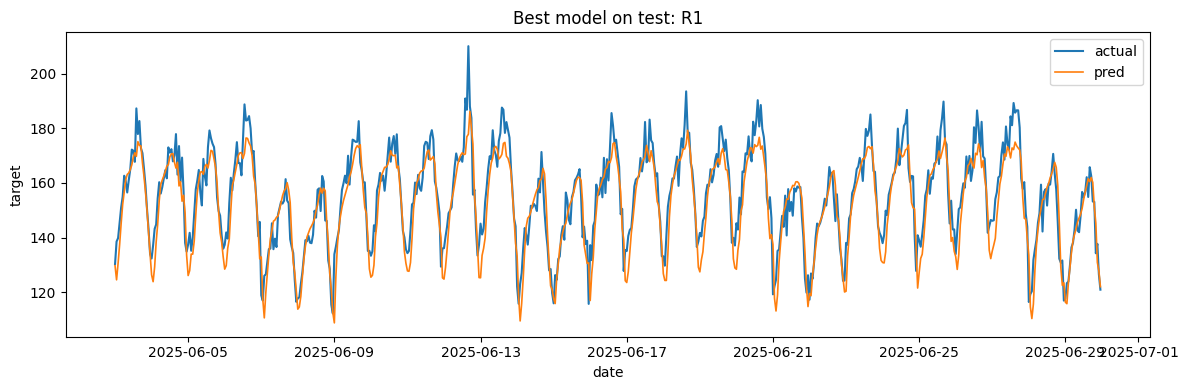

In [13]:
if best_exp == "R1":
    test_dates = df.iloc[max(window_size, val_end):n]["date"].values[:len(y_true_test)]
else:
    test_dates = feat_test["date"].values

plt.figure(figsize=(12, 4))
plt.plot(test_dates, y_true_test, label="actual", lw=1.5)
plt.plot(test_dates, y_pred_test, label="pred", lw=1.2)
plt.title(f"Best model on test: {best_exp}")
plt.xlabel("date")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=140)
plt.show()

In [14]:
runs_columns = [
    "experiment_id", "task", "dataset", "seed", "split_summary",
    "window_size", "horizon", "model_summary", "features_summary",
    "scaler", "optimizer", "lr", "epochs_trained",
    "best_val_mae", "best_val_rmse", "best_val_mape",
    "test_mae", "test_rmse", "test_mape", "notes"
]

split_summary = f"{len(train_df)}/{len(val_df)}/{len(test_df)} ({train_end}/{val_end}/{n})"

rows = []
rows.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": "",
    "horizon": 1,
    "model_summary": "naive-last",
    "features_summary": "lag_1 as prediction",
    "scaler": "",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_mae": metrics_b1_val["mae"],
    "best_val_rmse": metrics_b1_val["rmse"],
    "best_val_mape": metrics_b1_val["mape"],
    "test_mae": best_test_metrics["mae"] if best_exp == "B1" else np.nan,
    "test_rmse": best_test_metrics["rmse"] if best_exp == "B1" else np.nan,
    "test_mape": best_test_metrics["mape"] if best_exp == "B1" else np.nan,
    "notes": "",
})
rows.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": 24,
    "horizon": 1,
    "model_summary": "moving-average",
    "features_summary": "rolling mean 24 (shifted)",
    "scaler": "",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_mae": metrics_b2_val["mae"],
    "best_val_rmse": metrics_b2_val["rmse"],
    "best_val_mape": metrics_b2_val["mape"],
    "test_mae": best_test_metrics["mae"] if best_exp == "B2" else np.nan,
    "test_rmse": best_test_metrics["rmse"] if best_exp == "B2" else np.nan,
    "test_mape": best_test_metrics["mape"] if best_exp == "B2" else np.nan,
    "notes": "",
})
rows.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": "",
    "horizon": 1,
    "model_summary": "Ridge(alpha=1.0)",
    "features_summary": "lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dow,hour",
    "scaler": "StandardScaler(features)",
    "optimizer": "",
    "lr": "",
    "epochs_trained": 0,
    "best_val_mae": metrics_b3_val["mae"],
    "best_val_rmse": metrics_b3_val["rmse"],
    "best_val_mape": metrics_b3_val["mape"],
    "test_mae": best_test_metrics["mae"] if best_exp == "B3" else np.nan,
    "test_rmse": best_test_metrics["rmse"] if best_exp == "B3" else np.nan,
    "test_mape": best_test_metrics["mape"] if best_exp == "B3" else np.nan,
    "notes": "",
})
rows.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset.csv",
    "seed": SEED,
    "split_summary": split_summary,
    "window_size": window_size,
    "horizon": horizon,
    "model_summary": "GRU(hidden=64,layers=1)",
    "features_summary": "univariate target window",
    "scaler": "StandardScaler(target)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": epochs,
    "best_val_mae": metrics_r1_val["mae"],
    "best_val_rmse": metrics_r1_val["rmse"],
    "best_val_mape": metrics_r1_val["mape"],
    "test_mae": best_test_metrics["mae"] if best_exp == "R1" else np.nan,
    "test_rmse": best_test_metrics["rmse"] if best_exp == "R1" else np.nan,
    "test_mape": best_test_metrics["mape"] if best_exp == "R1" else np.nan,
    "notes": "selected_by_val_mae" if best_exp == "R1" else "",
})

runs_df = pd.DataFrame(rows, columns=runs_columns)
runs_df.to_csv(ARTIFACTS_DIR / "runs.csv", index=False)
runs_df

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,3024/648/648 (3024/3672/4320),,1,naive-last,lag_1 as prediction,,,,0,6.444815,8.201023,4.397922,NaN,NaN,NaN,
1,B2,forecasting,S12-hw-dataset.csv,42,3024/648/648 (3024/3672/4320),24,1,moving-average,rolling mean 24 (shifted),,,,0,13.397980,16.169904,9.198834,NaN,NaN,NaN,
2,B3,forecasting,S12-hw-dataset.csv,42,3024/648/648 (3024/3672/4320),,1,Ridge(alpha=1.0),"lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_...",StandardScaler(features),,,0,6.363156,7.888788,4.283608,NaN,NaN,NaN,
3,R1,forecasting,S12-hw-dataset.csv,42,3024/648/648 (3024/3672/4320),24,1,"GRU(hidden=64,layers=1)",univariate target window,StandardScaler(target),Adam,0.001,20,5.412138,6.926396,3.670032,6.011308,7.636511,3.910676,selected_by_val_mae
